Import Data

- Asset Reports
        - Asset Reports FY20-FY24 Format 4.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import re

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


In [ ]:
asset_report_4_path = 'data/Asset Reports/Asset Report FY20-FY24 Format 4.csv'

In [3]:
ar4 = pd.read_csv(asset_report_4_path, low_memory=False)


### Format 4

In [4]:
print("Shape:", ar4.shape)
ar4.head()

Shape: (78927, 22)


,Loc,PLACE,REGION,SVC,Asset,SerialNum,Type,Desc,Aquire,Effective,...,MFG,LNAME,FONUM,FOSHORT,Cat,Year,Age,FY,lat,long
0,194.0,Floor,Europe,Army,337961.0,337961-B170503048,3617.0,BAL WAVE ULT FE OLVERA ST MLP,11/15/2017,2/16/2018,...,BAL,IRISH PUB,2,KAISERSLAUTERN,NaN,2017,0.0,2020.0,49.440066,7.749126
1,194.0,Floor,Europe,Army,337198.0,337198-XAR671628,1371.0,AIN/A560 MULTI WIN2 (SAP-MJP),11/30/2016,1/27/2017,...,AIN,IRISH PUB,2,KAISERSLAUTERN,NaN,2016,0.0,2020.0,49.440066,7.749126
2,194.0,Floor,Europe,Army,337199.0,337199-XAR671629,1373.0,AIN A560 MULTI WIN4 (SAP-MJP),11/30/2016,1/27/2017,...,AIN,IRISH PUB,2,KAISERSLAUTERN,NaN,2016,0.0,2020.0,49.440066,7.749126
3,194.0,Floor,Europe,Army,337200.0,337200-XAR671630,1375.0,AIN/A560 MULTI WIN5 (SAP-MJP),11/30/2016,1/27/2017,...,AIN,IRISH PUB,2,KAISERSLAUTERN,NaN,2016,0.0,2020.0,49.440066,7.749126
4,194.0,Floor,Europe,Army,337201.0,337201-XAR671631,1377.0,AIN/A560 MULTI WIN13 (SAP-MJP),11/30/2016,1/27/2017,...,AIN,IRISH PUB,2,KAISERSLAUTERN,NaN,2016,0.0,2020.0,49.440066,7.749126


In [ ]:
#Data Cleaning and Feature Engineering
ar4["FY_int"] = pd.to_numeric(ar4["FY"], errors="coerce").astype("Int64")

ar4["Aquire_dt"] = pd.to_datetime(ar4["Aquire"], errors="coerce")
ar4["Year_acquire"] = ar4["Aquire_dt"].dt.year


ar4["Type_str"] = ar4["Type"].astype(str)


def extract_cat_from_foshort(x):
    x = str(x).upper().strip()
    if x.endswith(" SLOT"):
        return "SLOT"
    if x.endswith(" FRS"):
        return "FRS"
    if "ACM" in x or "ITC" in x:
        return "ACM/ITC"
    return None  


foshort_cat = ar4["FOSHORT"].apply(extract_cat_from_foshort)



def clean_base(x):
    x = str(x).strip()
    x = x.replace(" SLOT", "").replace(" FRS", "")
    x = x.replace(" ACM/ITC", "").replace(" ACM", "").replace(" ITC", "")
    return x.strip()

ar4["Base_clean"] = ar4["FOSHORT"].astype(str).apply(clean_base)

ar4["Base_clean"] = ar4["Base_clean"].str.replace(r"^SOUDA$", "SOUDA BAY", regex=True, case=False)

original_cat = ar4["Cat"].astype(str).str.strip().str.upper().replace("NAN", None)

ar4["Cat_clean"] = foshort_cat.copy()

ar4["Cat_clean"] = ar4["Cat_clean"].fillna(original_cat)

ar4["Cat_clean"] = ar4["Cat_clean"].replace("NAN", pd.NA)

ar4[["FOSHORT", "Base_clean", "Cat", "Cat_clean"]].head()

,FOSHORT,Base_clean,Cat,Cat_clean
0,KAISERSLAUTERN,KAISERSLAUTERN,NaN,None
1,KAISERSLAUTERN,KAISERSLAUTERN,NaN,None
2,KAISERSLAUTERN,KAISERSLAUTERN,NaN,None
3,KAISERSLAUTERN,KAISERSLAUTERN,NaN,None
4,KAISERSLAUTERN,KAISERSLAUTERN,NaN,None


In [6]:
print("Category (Cat_clean) distribution:")
print(ar4["Cat_clean"].value_counts(dropna=False).head(10))

print("\nFiscal years present:")
print(ar4["FY_int"].value_counts().sort_index())

print("\nSample of Base vs Category:")
print(ar4[["Base_clean", "Cat_clean"]].drop_duplicates().head(15))


Category (Cat_clean) distribution:
Cat_clean
SLOT       60817
None        8406
ACM/ITC     7345
FRS         2359
Name: count, dtype: int64

Fiscal years present:
FY_int
2020    20666
2021     6831
2022    28930
2023    22267
Name: count, dtype: Int64

Sample of Base vs Category:
          Base_clean Cat_clean
0     KAISERSLAUTERN      None
136        STUTTGART      None
245          VICENZA      None
266          VILSECK      None
348          ANSBACH      None
392            SEOUL      None
532        UIJEONGBU      None
606        PYONGTAEK      None
634            DAEGU      None
737             ZAMA      None
821          OKINAWA      None
1121         IWAKUNI      None
1162       WIESBADEN      None
1370        GARMISCH      None
1449          NAPLES      None


In [7]:
# Category-Level Trend Over Time (SLOT vs FRS vs ACM/ITC)
main_cats = ["SLOT", "FRS", "ACM/ITC"]

cat_filtered = ar4[
    ar4["Cat_clean"].isin(main_cats) & ar4["FY_int"].notna()
]

cat_year = (
    cat_filtered
    .groupby(["Cat_clean", "FY_int"])
    .size()
    .reset_index(name="count")
)

cat_year

,Cat_clean,FY_int,count
0,ACM/ITC,2020,1377
1,ACM/ITC,2021,740
2,ACM/ITC,2022,3107
3,ACM/ITC,2023,2099
4,FRS,2020,450
5,FRS,2021,236
6,FRS,2022,1009
7,FRS,2023,657
8,SLOT,2020,10838
9,SLOT,2021,5855


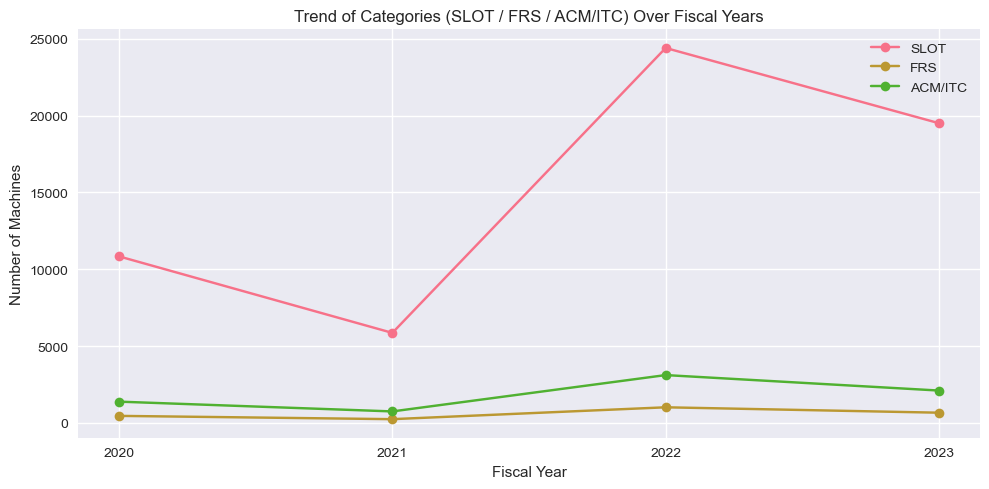

In [ ]:
# Plotting the trends
plt.figure(figsize=(10, 5))

for cat in main_cats:
    sub = cat_year[cat_year["Cat_clean"] == cat]
    if sub.empty:
        continue
    plt.plot(sub["FY_int"], sub["count"], marker="o", label=cat)

plt.xlabel("Fiscal Year")
plt.ylabel("Number of Machines")
plt.title("Trend of Categories (SLOT / FRS / ACM/ITC) Over Fiscal Years")
plt.xticks(sorted(cat_year["FY_int"].dropna().unique()))
plt.legend()
plt.tight_layout()
plt.show()


In [9]:
#Trend Lines for Top Machine Types
def most_common_cat(x):
    x_nonnull = x.dropna()
    if x_nonnull.empty:
        return "UNKNOWN"     # fallback when no category is available for this type
    return x_nonnull.value_counts().idxmax()

type_cat_map = (
    ar4.groupby("Type_str")["Cat_clean"]
      .apply(most_common_cat)
      .to_dict()
)


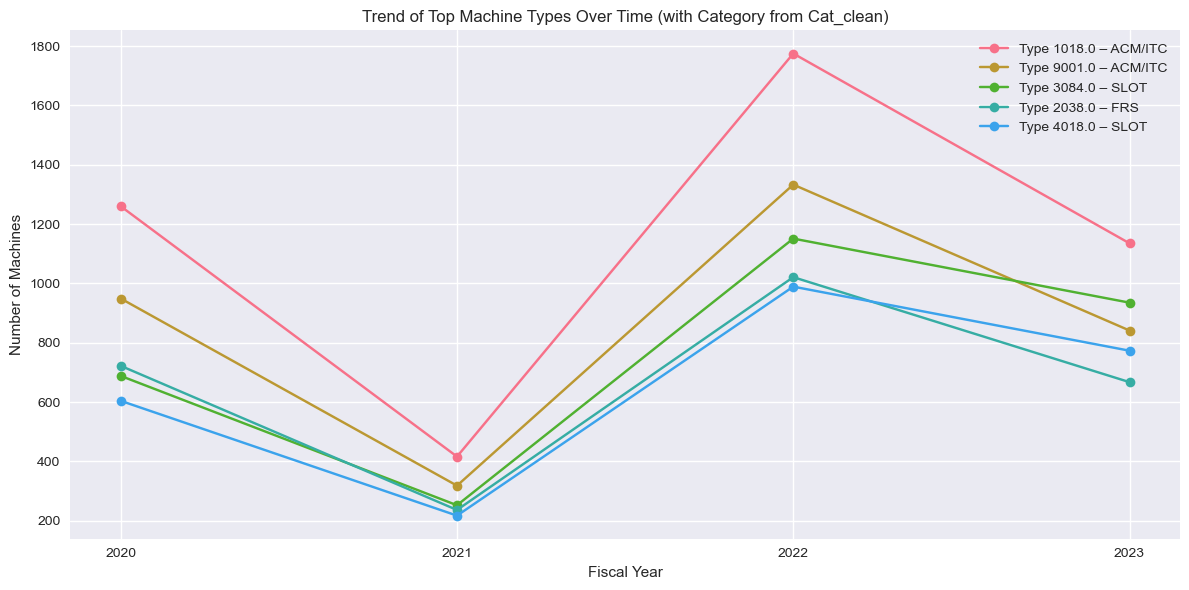

In [10]:
# Build type-year table across all bases
type_year = (
    ar4.dropna(subset=["FY_int"])
      .groupby(["Type_str", "FY_int"])
      .size()
      .reset_index(name="count")
)

# Select TOP N machine types overall
TOP_N = 5
top_types = (
    type_year.groupby("Type_str")["count"]
             .sum()
             .nlargest(TOP_N)
             .index
)

plot_data = type_year[type_year["Type_str"].isin(top_types)]


plt.figure(figsize=(12, 6))

for t in top_types:
    sub = plot_data[plot_data["Type_str"] == t]
    cat = type_cat_map.get(t, "UNKNOWN")
    label = f"Type {t} – {cat}"
    plt.plot(sub["FY_int"], sub["count"], marker="o", label=label)

plt.xlabel("Fiscal Year")
plt.ylabel("Number of Machines")
plt.title("Trend of Top Machine Types Over Time (with Category from Cat_clean)")
plt.xticks(sorted(plot_data["FY_int"].dropna().unique()))
plt.legend()
plt.tight_layout()
plt.show()


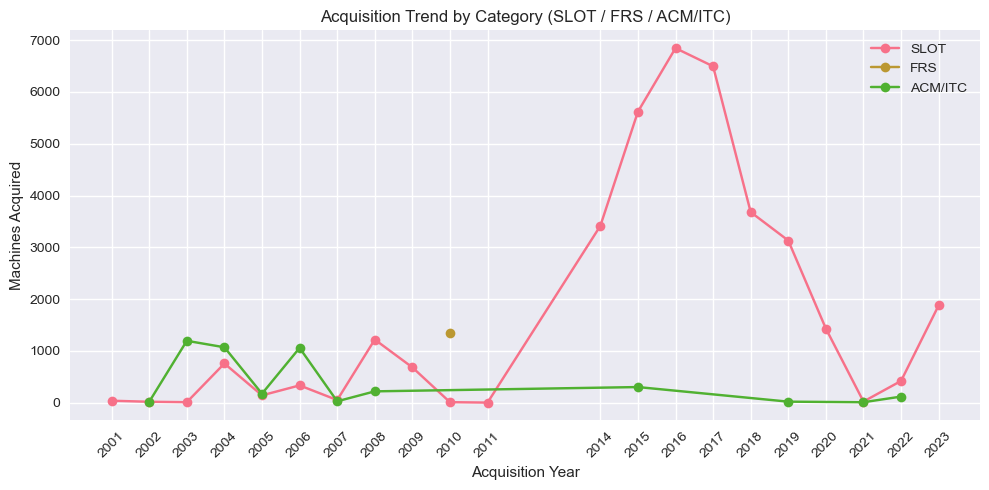

In [11]:
# Acquisition-Based Category Trend
acq_cat = (
    ar4.dropna(subset=["Year_acquire"])  
      .groupby(["Cat_clean", "Year_acquire"])
      .size()
      .reset_index(name="count")
)

acq_cat_main = acq_cat[acq_cat["Cat_clean"].isin(main_cats)]

plt.figure(figsize=(10, 5))

for cat in main_cats:
    sub = acq_cat_main[acq_cat_main["Cat_clean"] == cat]
    if sub.empty:
        continue
    plt.plot(sub["Year_acquire"], sub["count"], marker="o", label=cat)

plt.xlabel("Acquisition Year")
plt.ylabel("Machines Acquired")
plt.title("Acquisition Trend by Category (SLOT / FRS / ACM/ITC)")
plt.xticks(sorted(acq_cat_main["Year_acquire"].dropna().unique()), rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Machine Category Trends for Specific Bases
def plot_all_categories_for_base(df, base_name, region_name=None):
    """
    Plots SLOT, FRS, and ACM/ITC machine trends on the SAME graph
    for a specific base across all fiscal years.
    If region_name is provided, it will be added to the title.
    """

    categories = ["SLOT", "FRS", "ACM/ITC"]
    colors = ["blue", "orange", "green"]

    plt.figure(figsize=(10,5))

    found_any = False

    for cat, color in zip(categories, colors):
        base_cat = ar4[
            (df["Base_clean"] == base_name) &
            (df["Cat_clean"] == cat)
        ]

        if base_cat.empty:
            continue  
        found_any = True

        
        trend = (
            base_cat.groupby("FY_int")
                    .size()
                    .reset_index(name=f"{cat}_count")
                    .sort_values("FY_int")
        )

        plt.plot(
            trend["FY_int"],
            trend[f"{cat}_count"],
            marker="o",
            linewidth=2,
            color=color,
            label=cat
        )

    if not found_any:
        print(f"No SLOT/FRS/ACM/ITC data for base: {base_name}")
        plt.close()
        return

    if region_name:
        title = f"Machine Category Trends Over Years – {base_name} ({region_name})"
    else:
        title = f"Machine Category Trends Over Years – {base_name}"

    plt.title(title)
    plt.xlabel("Fiscal Year")
    plt.ylabel("Number of Machines count")
    plt.xticks(sorted(ar4["FY_int"].dropna().unique()))
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


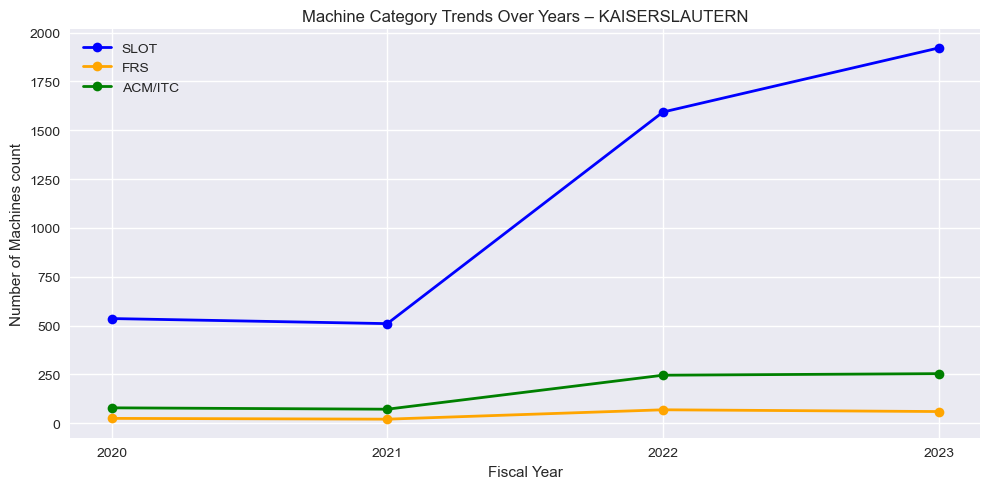

In [13]:
plot_all_categories_for_base(ar4, "KAISERSLAUTERN")

In [14]:
# Region and Base Analysis
print(ar4["REGION"].value_counts())
print(ar4[["REGION", "Base_clean"]].head())

base_region_counts = (
    ar4.dropna(subset=["REGION", "Base_clean"])
      .groupby(["REGION", "Base_clean"])
      .size()
      .reset_index(name="machine_count")
)

# top 5 bases by machine count
top_bases_per_region = (
    base_region_counts
    .sort_values(["REGION", "machine_count"], ascending=[True, False])
    .groupby("REGION")
    .head(5)
)

top_bases_per_region

REGION
Europe    31951
Japan     29690
Korea     17283
Name: count, dtype: int64
   REGION      Base_clean
0  Europe  KAISERSLAUTERN
1  Europe  KAISERSLAUTERN
2  Europe  KAISERSLAUTERN
3  Europe  KAISERSLAUTERN
4  Europe  KAISERSLAUTERN


,REGION,Base_clean,machine_count
3,Europe,KAISERSLAUTERN,6959
10,Europe,VILSECK,4619
11,Europe,WIESBADEN,3658
8,Europe,STUTTGART,3543
9,Europe,VICENZA,3086
14,Japan,OKINAWA,13641
17,Japan,ZAMA,5833
16,Japan,YOKOSUKA,4802
15,Japan,SASEBO,2887
13,Japan,IWAKUNI,2527


In [ ]:
# Mapping regions to their top bases
region_to_bases = (
    top_bases_per_region
    .groupby("REGION")["Base_clean"]
    .apply(list)
    .to_dict()
)

region_to_bases


{'Europe': ['KAISERSLAUTERN', 'VILSECK', 'WIESBADEN', 'STUTTGART', 'VICENZA'],
 'Japan': ['OKINAWA', 'ZAMA', 'YOKOSUKA', 'SASEBO', 'IWAKUNI'],
 'Korea': ['PYONGTAEK', 'DAEGU', 'SEOUL', 'UIJEONGBU', 'SINGAPORE']}


=== Region: Europe ===
Plotting for base: KAISERSLAUTERN


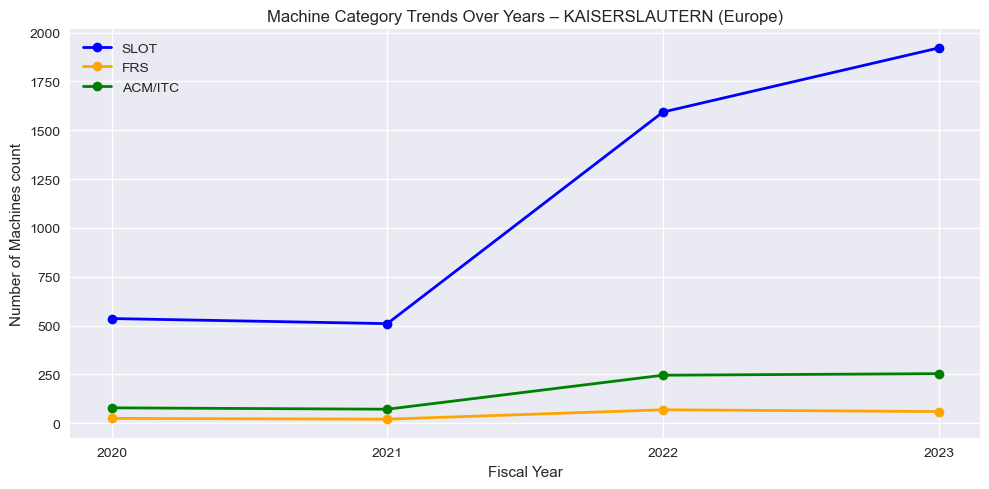

Plotting for base: VILSECK


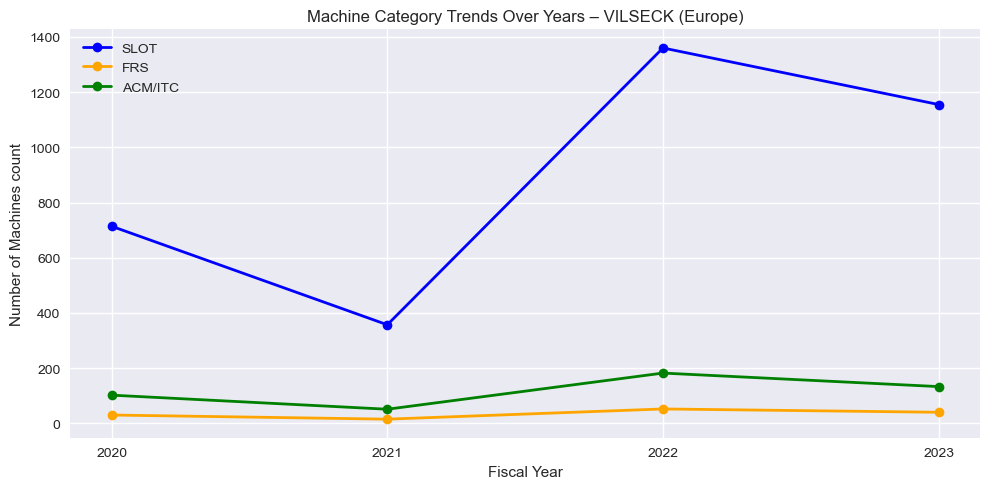

Plotting for base: WIESBADEN


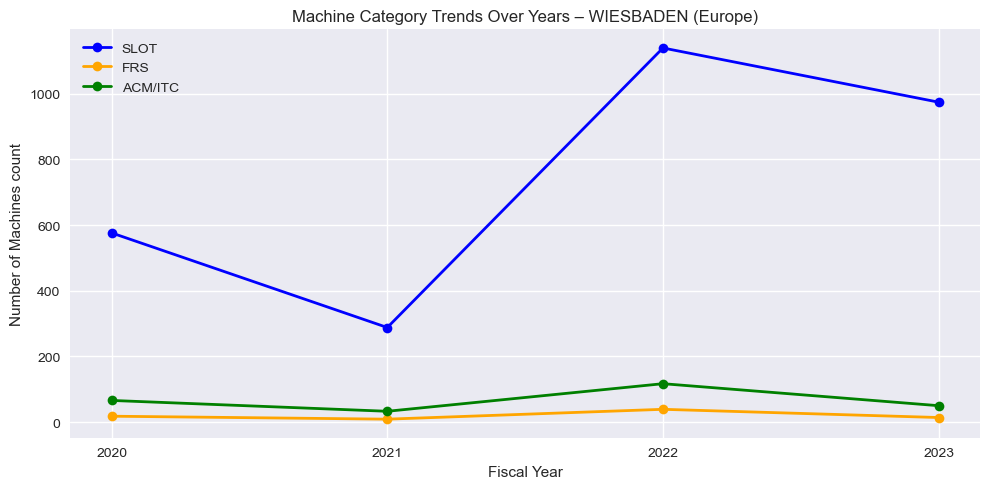

Plotting for base: STUTTGART


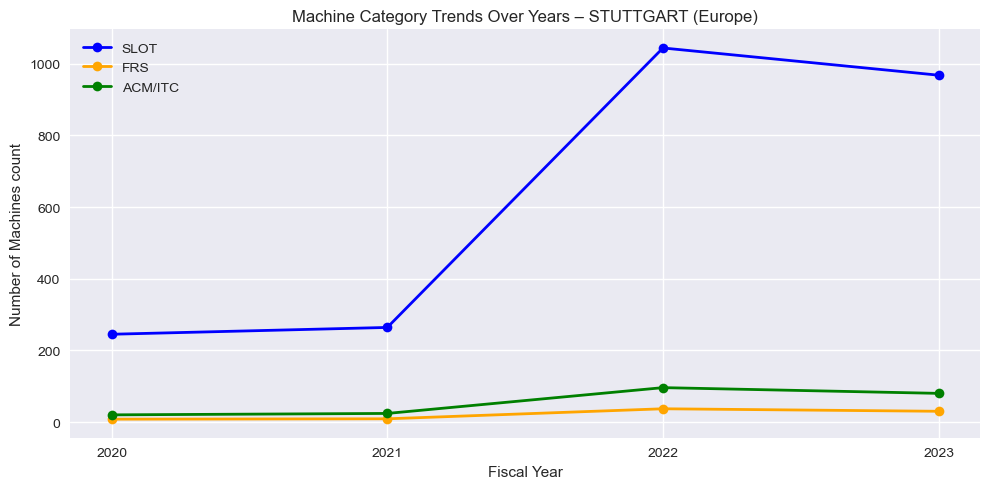

Plotting for base: VICENZA


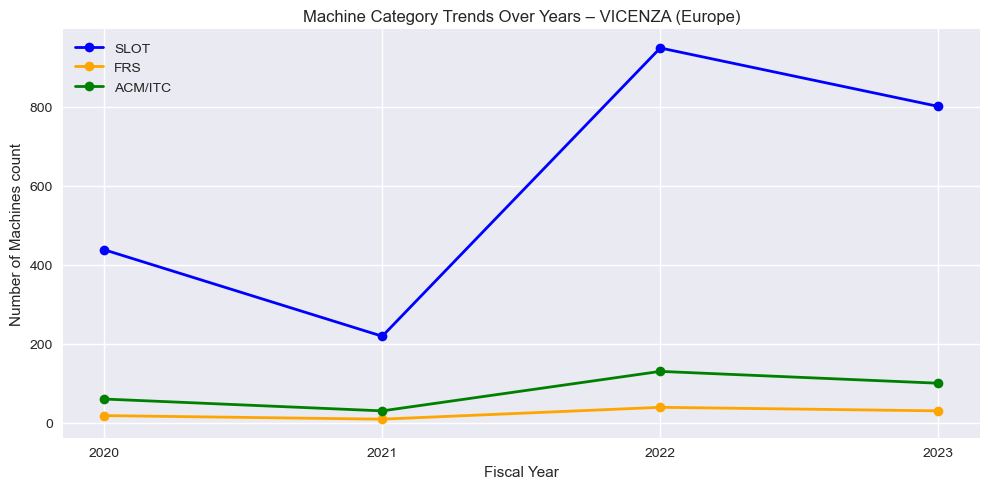


=== Region: Japan ===
Plotting for base: OKINAWA


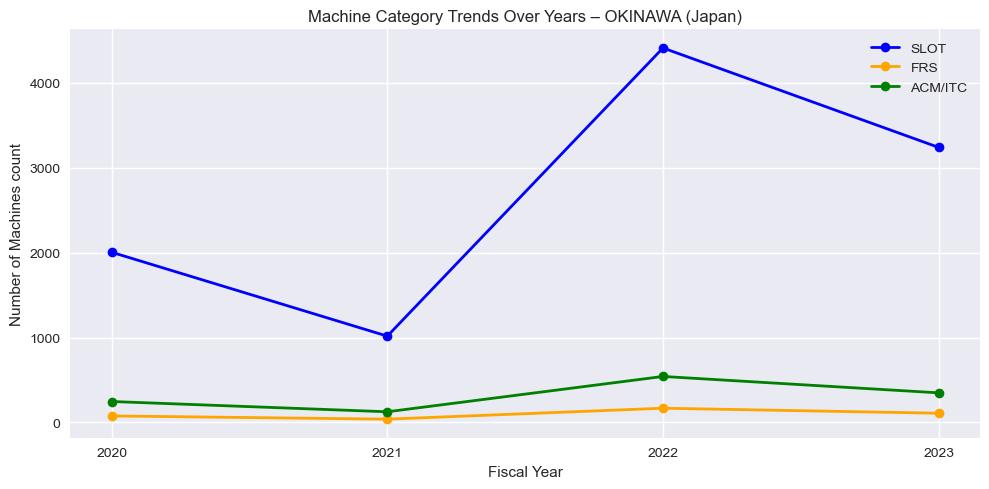

Plotting for base: ZAMA


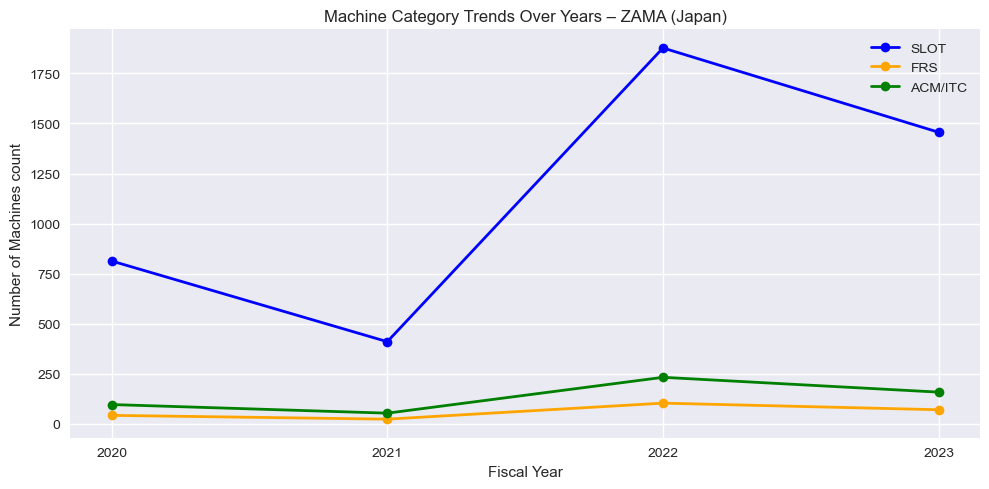

Plotting for base: YOKOSUKA


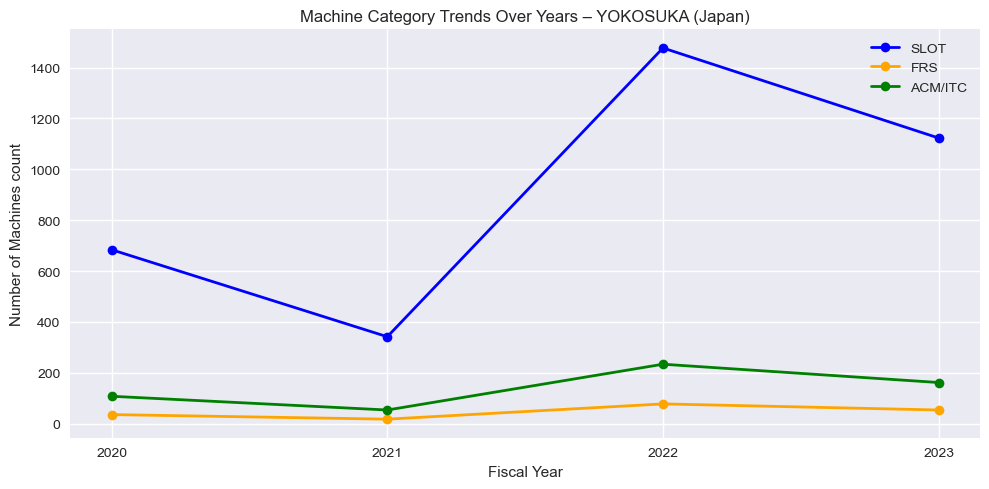

Plotting for base: SASEBO


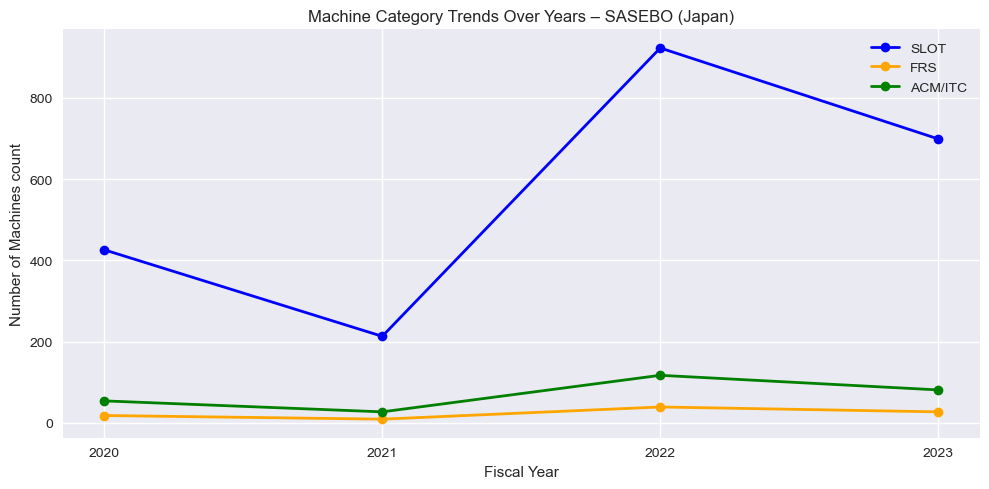

Plotting for base: IWAKUNI


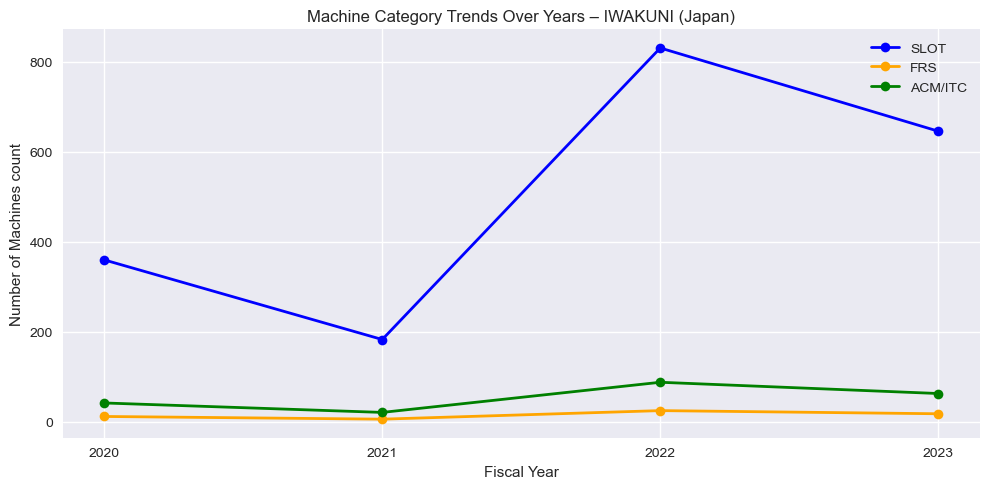


=== Region: Korea ===
Plotting for base: PYONGTAEK


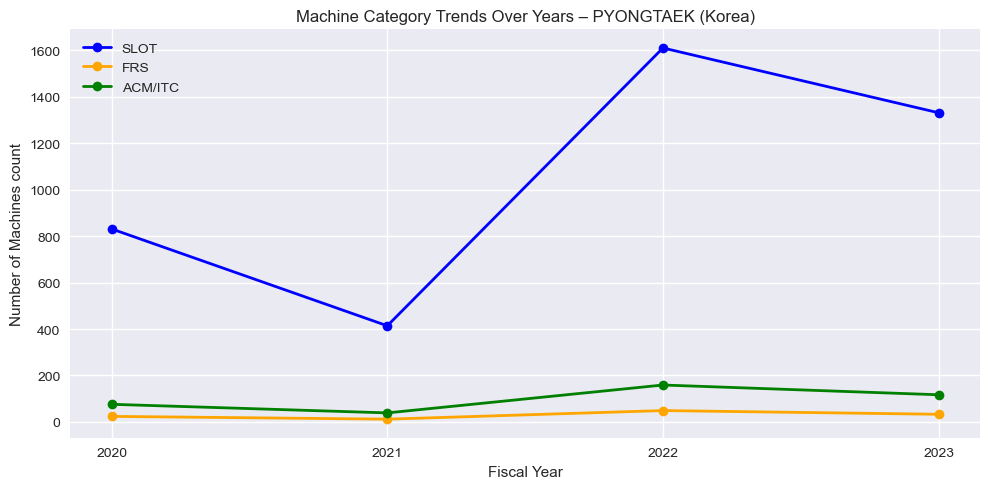

Plotting for base: DAEGU


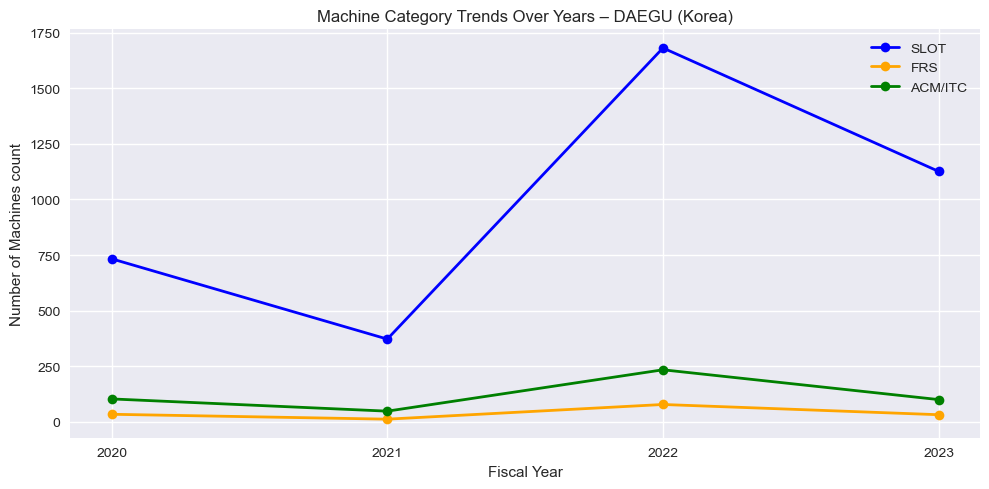

Plotting for base: SEOUL


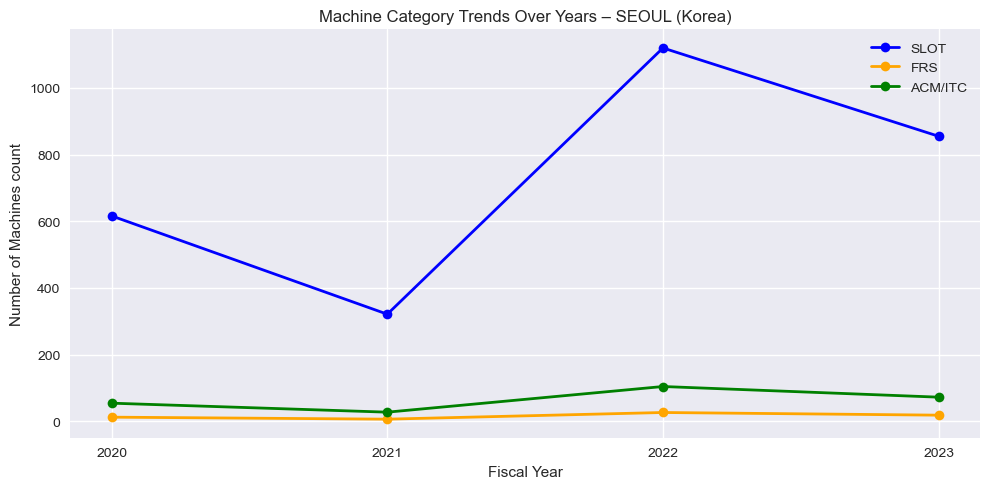

Plotting for base: UIJEONGBU


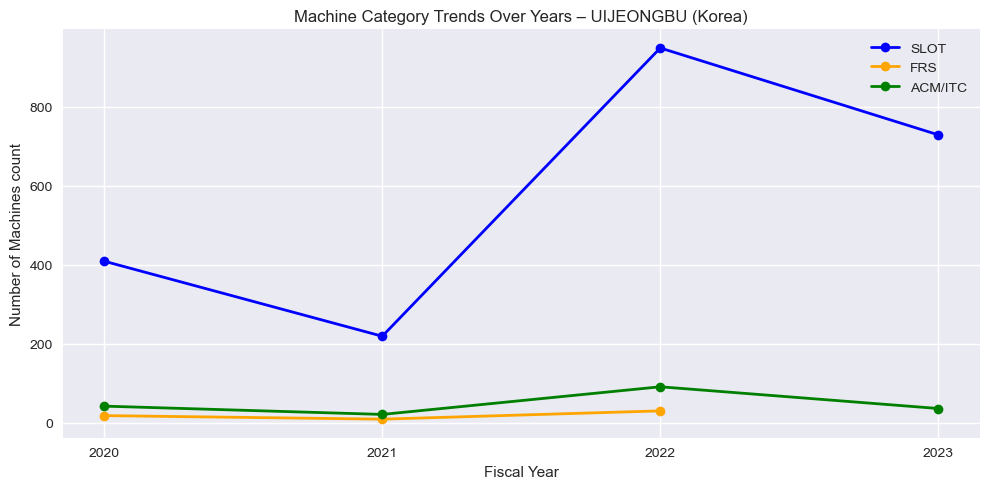

Plotting for base: SINGAPORE


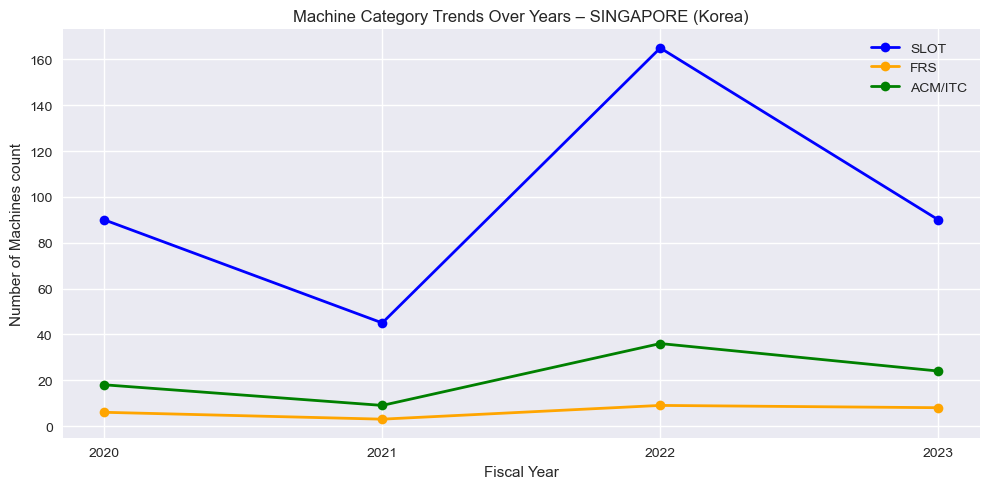

In [ ]:
# Plotting for each region and its top bases
for region, base_list in region_to_bases.items():
    print(f"\n=== Region: {region} ===")
    for base in base_list:
        print(f"Plotting for base: {base}")
        plot_all_categories_for_base(ar4, base, region_name=region)

In [17]:
# Slot Machine Count Per Base Per Year

slot_df = ar4[ar4["Cat_clean"] == "SLOT"].copy()

slot_base_year_table = (
    slot_df
    .dropna(subset=["Base_clean", "FY_int"])
    .groupby(["Base_clean", "FY_int"])
    .size()
    .reset_index(name="slot_count")
    .pivot(index="Base_clean", columns="FY_int", values="slot_count")
    .fillna(0)
    .astype(int)
)

slot_base_year_table


FY_int,2020,2021,2022,2023
Base_clean,,,,
ANSBACH,216,108,468,396
DAEGU,733,372,1681,1126
GARMISCH,138,69,283,167
IWAKUNI,360,183,831,646
KAISERSLAUTERN,536,510,1593,1921
NAPLES,282,141,611,517
OKINAWA,2005,1017,4411,3240
PYONGTAEK,831,414,1610,1331
ROTA,366,171,741,682


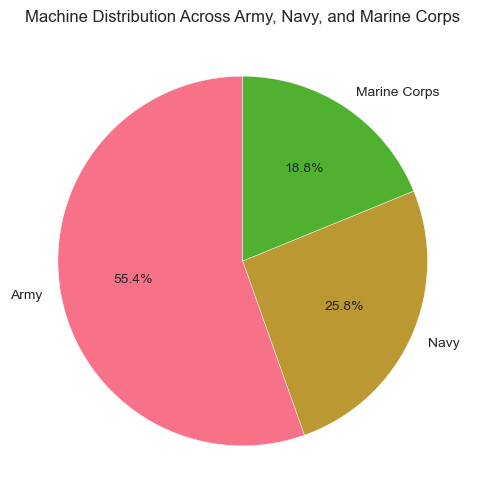

In [18]:
# Machine Distribution by branch
ar4["SVC_clean"] = (
    ar4["SVC"]
    .astype(str)
    .str.extract(r"(Army|Navy|Marine Corps)", expand=False)
)

branch_counts = ar4["SVC_clean"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    branch_counts,
    labels=branch_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)
plt.title("Machine Distribution Across Army, Navy, and Marine Corps")
plt.show()

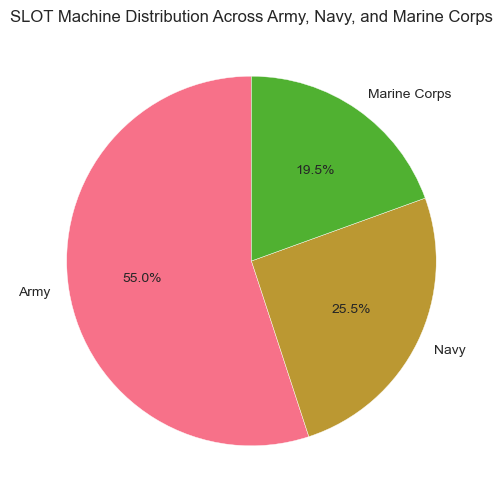

In [19]:
# Slot Machine Distribution by branch
slot_df = ar4[ar4["Cat_clean"] == "SLOT"]

slot_branch_counts = slot_df["SVC_clean"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    slot_branch_counts,
    labels=slot_branch_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)
plt.title("SLOT Machine Distribution Across Army, Navy, and Marine Corps")
plt.show()


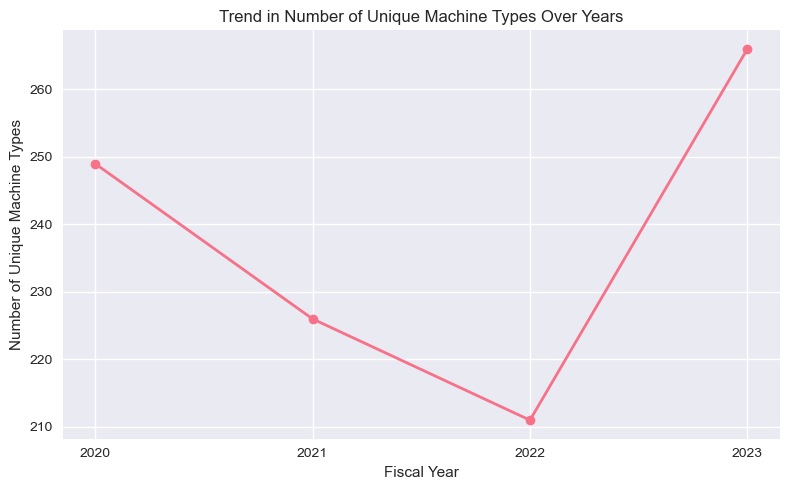

In [20]:
# Count how many distinct machine Types exist each Fiscal Year
types_per_year = (
    ar4.dropna(subset=["FY_int", "Type_str"])
      .groupby("FY_int")["Type_str"]
      .nunique()
      .reset_index(name="unique_types")
      .sort_values("FY_int")
)

# Plot
plt.figure(figsize=(8,5))
plt.plot(types_per_year["FY_int"], types_per_year["unique_types"], marker="o", linewidth=2)
plt.title("Trend in Number of Unique Machine Types Over Years")
plt.xlabel("Fiscal Year")
plt.ylabel("Number of Unique Machine Types")
plt.xticks(types_per_year["FY_int"])
plt.grid(True)
plt.tight_layout()
plt.show()


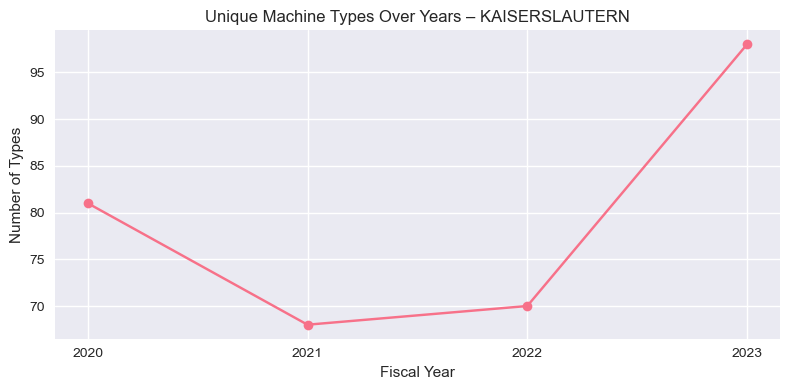

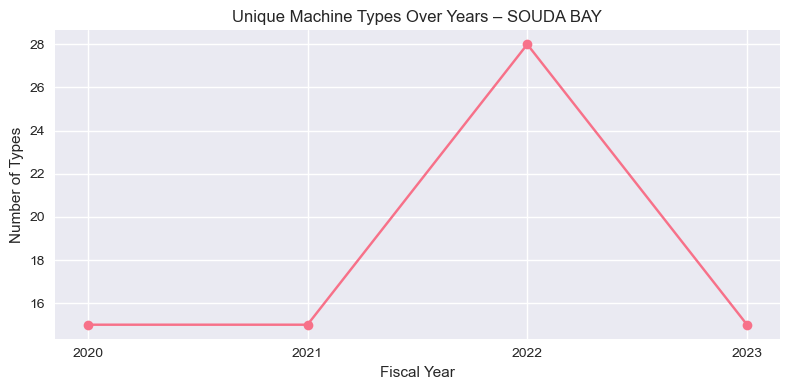

In [ ]:
# Unique Machine Types Per Base Over Time
def plot_unique_types_per_base(df, base_name):
    base_df = ar4[df["Base_clean"] == base_name]

    types_year = (
        base_df.dropna(subset=["FY_int", "Type_str"])
               .groupby("FY_int")["Type_str"]
               .nunique()
               .reset_index(name="unique_types")
               .sort_values("FY_int")
    )

    if types_year.empty:
        print(f"No data for base: {base_name}")
        return

    plt.figure(figsize=(8,4))
    plt.plot(types_year["FY_int"], types_year["unique_types"], marker="o")
    plt.title(f"Unique Machine Types Over Years – {base_name}")
    plt.xlabel("Fiscal Year")
    plt.ylabel("Number of Types")
    plt.xticks(types_year["FY_int"])
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_unique_types_per_base(ar4, "KAISERSLAUTERN")
plot_unique_types_per_base(ar4, "SOUDA BAY")
